# COAD Clinical Data Analysis Report

**Date:** 2026-06-13  
**Dataset:** TCGA COAD clinical data from `bio_tcga.tcga_cdr_tcga_cdr`  
**Cancer type:** COAD means colon adenocarcinoma (a type of colon cancer / 一种结肠癌).

This notebook answers three clinical questions:

1. What is the age distribution of COAD patients?
2. Are survival rates different across stage (cancer development level / 癌症发展程度)?
3. Which factor is more related to prognosis (the patient's later outcome / 病人之后的结果): age, gender, or stage?

Key methods:

- Kaplan-Meier curve (a curve estimating survival probability over follow-up time / 估计随访期间生存概率的曲线).
- Log-rank test (a statistical test comparing survival curves / 比较生存曲线是否不同的统计检验).
- Cox proportional hazards regression (a survival model estimating death risk while using follow-up time / 使用随访时间估计死亡风险的生存模型).


## Metric Definitions

- **Patient grain:** one row per TCGA COAD patient.
- **Age:** age at initial pathologic diagnosis, in years.
- **Stage:** AJCC pathologic tumor stage, simplified from detailed values like Stage IIA or Stage IIIB into Stage I, II, III, or IV.
- **Overall survival (OS):** time from diagnosis to death or last follow-up (总生存时间：从诊断到死亡或最后一次随访的时间).
- **Event:** `1` means death was observed; `0` means censored (the patient was still alive or death was not observed at last follow-up / 随访结束时还活着或没有观察到死亡).

Important caveat: this is an observational clinical dataset (not a randomized experiment / 不是随机实验), so the analysis shows association, not proof of causation.


In [1]:
from pathlib import Path
import os
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 130

REPORT_DIR = Path.cwd()
if REPORT_DIR.name != "reports":
    REPORT_DIR = Path("/workspace/coad-predictor-model/reports")
REPORT_DIR.mkdir(parents=True, exist_ok=True)
PROJECT_ROOT = REPORT_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from src import config as project_config
except Exception:
    project_config = None


def get_db_setting(env_name, config_name, default=None):
    value = os.getenv(env_name)
    if value:
        return value
    if project_config is not None and hasattr(project_config, config_name):
        return getattr(project_config, config_name)
    return default


def make_engine():
    """Create a database engine for this project notebook.

    Priority:
    1. Environment variables, useful for custom runs.
    2. The project's src/config.py defaults, useful when running inside the Jupyter container.
    """
    host = get_db_setting("PGHOST", "DB_HOST", "bio-postgres")
    port = int(get_db_setting("PGPORT", "DB_PORT", 5432))
    database = get_db_setting("PGDATABASE", "DB_NAME", "bio")
    user = get_db_setting("PGUSER", "DB_USER", "bio")
    password = get_db_setting("PGPASSWORD", "DB_PASSWORD")

    if not password:
        raise RuntimeError(
            "Database password was not found. Set PGPASSWORD or run from the "
            "coad-predictor-model project where src/config.py is available."
        )

    url = URL.create(
        "postgresql+psycopg2",
        username=user,
        password=password,
        host=host,
        port=port,
        database=database,
    )
    return create_engine(url)


engine = make_engine()
print("Analysis output directory:", REPORT_DIR)
print("Database host:", engine.url.host, "database:", engine.url.database)


Analysis output directory: /workspace/coad-predictor-model/reports


## Load and Clean COAD Clinical Data

The query reads only the clinical columns needed for this report. Missing clinical placeholders such as `#N/A` and `[Not Available]` are converted to real missing values.


In [2]:
query = """
SELECT
    bcr_patient_barcode AS patient_id,
    NULLIF(age_at_initial_pathologic_diagnosis, '#N/A')::double precision AS age,
    gender,
    ajcc_pathologic_tumor_stage AS stage_raw,
    vital_status,
    NULLIF(os, '#N/A')::integer AS os_event,
    NULLIF(os_time, '#N/A')::double precision AS os_time_days
FROM bio_tcga.tcga_cdr_tcga_cdr
WHERE type = 'COAD'
ORDER BY bcr_patient_barcode;
"""

df = pd.read_sql_query(text(query), engine)
missing_tokens = {"#N/A", "[Not Available]", "[Not Applicable]", ""}
for col in ["gender", "stage_raw", "vital_status"]:
    df[col] = df[col].replace(list(missing_tokens), pd.NA)


def simplify_stage(value):
    if pd.isna(value):
        return pd.NA
    match = re.match(r"Stage\s+([IVX]+)", str(value))
    if not match:
        return pd.NA
    return f"Stage {match.group(1)}"


stage_order = ["Stage I", "Stage II", "Stage III", "Stage IV"]
stage_number = {stage: i + 1 for i, stage in enumerate(stage_order)}

df["stage_group"] = df["stage_raw"].map(simplify_stage)
df["stage_group"] = pd.Categorical(
    df["stage_group"], categories=stage_order, ordered=True
)
df["stage_number"] = df["stage_group"].map(stage_number).astype(float)

survival_df = df.dropna(subset=["os_time_days", "os_event"]).query(
    "os_time_days > 0"
).copy()

summary = pd.DataFrame(
    {
        "metric": [
            "Total COAD patients",
            "Patients with age",
            "Patients with stage I-IV",
            "Patients with usable OS",
            "Observed death events",
        ],
        "value": [
            len(df),
            int(df["age"].notna().sum()),
            int(df["stage_group"].notna().sum()),
            len(survival_df),
            int(survival_df["os_event"].sum()),
        ],
    }
)

display(summary)
display(df.head())

,metric,value
0,Total COAD patients,459
1,Patients with age,459
2,Patients with stage I-IV,448
3,Patients with usable OS,442
4,Observed death events,98


,patient_id,age,gender,stage_raw,vital_status,os_event,os_time_days,stage_group,stage_number
0,TCGA-3L-AA1B,61.0,FEMALE,Stage I,Alive,0,475.0,Stage I,1.0
1,TCGA-4N-A93T,67.0,MALE,Stage IIIB,Alive,0,146.0,Stage III,3.0
2,TCGA-4T-AA8H,42.0,FEMALE,Stage IIA,Alive,0,385.0,Stage II,2.0
3,TCGA-5M-AAT4,74.0,MALE,Stage IV,Dead,1,49.0,Stage IV,4.0
4,TCGA-5M-AAT6,40.0,FEMALE,Stage IV,Dead,1,290.0,Stage IV,4.0


## 1. Age Distribution

This section summarizes how old COAD patients were when the cancer was first pathologically diagnosed (confirmed by tissue/pathology test / 通过病理检查确认).


,value
n,459.0
mean_age,66.9
std_age,13.1
min_age,31.0
q1_age,58.0
median_age,68.0
q3_age,77.0
max_age,90.0


,age_group,patients,percent
0,<40,12,2.6
1,40-49,43,9.4
2,50-59,71,15.5
3,60-69,119,25.9
4,70-79,126,27.5
5,80+,88,19.2


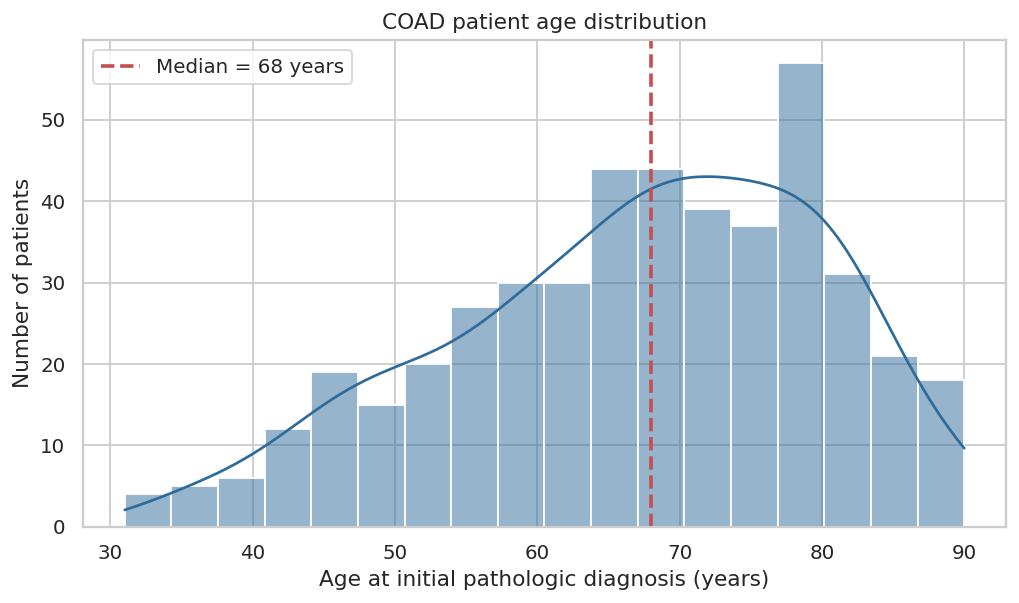

**Answer:** The median age is **68 years**, and the middle 50% of patients are about **58-77 years** old. The distribution is concentrated in older adults, which is expected for colon cancer.

In [3]:
age_stats = (
    df["age"]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .rename(
        {
            "count": "n",
            "mean": "mean_age",
            "std": "std_age",
            "min": "min_age",
            "25%": "q1_age",
            "50%": "median_age",
            "75%": "q3_age",
            "max": "max_age",
        }
    )
    .to_frame("value")
)
age_stats["value"] = age_stats["value"].round(1)

age_bins = pd.cut(
    df["age"],
    bins=[0, 40, 50, 60, 70, 80, 100],
    labels=["<40", "40-49", "50-59", "60-69", "70-79", "80+"],
    right=False,
)
age_bin_table = (
    age_bins.value_counts(sort=False).rename_axis("age_group").reset_index(name="patients")
)
age_bin_table["percent"] = (
    age_bin_table["patients"] / age_bin_table["patients"].sum() * 100
).round(1)

display(age_stats)
display(age_bin_table)

fig, ax = plt.subplots(figsize=(8, 4.8))
sns.histplot(
    df["age"].dropna(),
    bins=18,
    kde=True,
    color="#2F6B9A",
    edgecolor="white",
    ax=ax,
)
ax.axvline(
    df["age"].median(),
    color="#C44E52",
    linestyle="--",
    linewidth=2,
    label=f"Median = {df['age'].median():.0f} years",
)
ax.set_title("COAD patient age distribution")
ax.set_xlabel("Age at initial pathologic diagnosis (years)")
ax.set_ylabel("Number of patients")
ax.legend()
fig.tight_layout()
fig.savefig(REPORT_DIR / "coad_age_distribution.png", bbox_inches="tight")
plt.show()

display(
    Markdown(
        f"**Answer:** The median age is **{df['age'].median():.0f} years**, "
        f"and the middle 50% of patients are about **{df['age'].quantile(0.25):.0f}-"
        f"{df['age'].quantile(0.75):.0f} years** old. "
        "The distribution is concentrated in older adults, which is expected for colon cancer."
    )
)

In [4]:
stage_counts = (
    df["stage_group"].value_counts(sort=False, dropna=False)
    .rename_axis("stage_group")
    .reset_index(name="patients")
)
gender_counts = (
    df["gender"].value_counts(dropna=False)
    .rename_axis("gender")
    .reset_index(name="patients")
)

display(stage_counts)
display(gender_counts)

,stage_group,patients
0,Stage I,76
1,Stage II,178
2,Stage III,129
3,Stage IV,65
4,NaN,11


,gender,patients
0,MALE,243
1,FEMALE,216


## 2. Survival by Stage

Survival rate here means Kaplan-Meier estimated probability of being alive at a specific time point (这里的生存率指 Kaplan-Meier 估计的某个时间点仍然存活的概率).


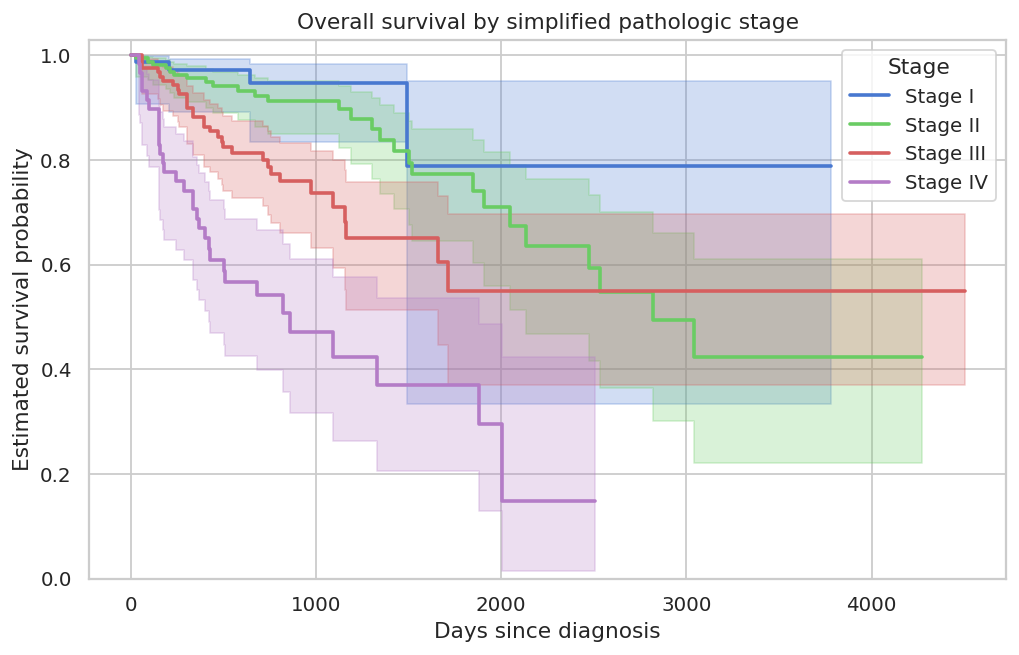

,stage,patients_with_os,death_events,1_year_survival,3_year_survival,5_year_survival
0,Stage I,74,4,97.2,94.6,78.9
1,Stage II,169,27,95.6,91.3,77.2
2,Stage III,127,31,88.2,71.1,55.0
3,Stage IV,61,31,68.8,42.3,37.1


**Log-rank test:** p = **3.98e-13**. A small p-value means the survival curves are unlikely to be identical (生存曲线很可能不同).

In [5]:
km_data = survival_df.dropna(subset=["stage_group"]).copy()
km_data["stage_group"] = km_data["stage_group"].astype(str)

rows = []
fig, ax = plt.subplots(figsize=(8, 5.2))
palette = dict(
    zip(stage_order, ["#4878D0", "#6ACC64", "#D65F5F", "#B47CC7"])
)

for stage in stage_order:
    group = km_data[km_data["stage_group"] == stage]
    if group.empty:
        continue
    kmf = KaplanMeierFitter()
    kmf.fit(group["os_time_days"], event_observed=group["os_event"], label=stage)
    kmf.plot_survival_function(
        ax=ax, ci_show=True, color=palette[stage], linewidth=2
    )
    estimates = kmf.survival_function_at_times([365.25, 365.25 * 3, 365.25 * 5])
    rows.append(
        {
            "stage": stage,
            "patients_with_os": len(group),
            "death_events": int(group["os_event"].sum()),
            "1_year_survival": estimates.iloc[0],
            "3_year_survival": estimates.iloc[1],
            "5_year_survival": estimates.iloc[2],
        }
    )

ax.set_title("Overall survival by simplified pathologic stage")
ax.set_xlabel("Days since diagnosis")
ax.set_ylabel("Estimated survival probability")
ax.set_ylim(0, 1.03)
ax.legend(title="Stage")
fig.tight_layout()
fig.savefig(REPORT_DIR / "coad_survival_by_stage_km.png", bbox_inches="tight")
plt.show()

survival_rate_table = pd.DataFrame(rows)
for col in ["1_year_survival", "3_year_survival", "5_year_survival"]:
    survival_rate_table[col] = (survival_rate_table[col] * 100).round(1)

logrank = multivariate_logrank_test(
    event_durations=km_data["os_time_days"],
    groups=km_data["stage_group"],
    event_observed=km_data["os_event"],
)

display(survival_rate_table)
display(
    Markdown(
        f"**Log-rank test:** p = **{logrank.p_value:.2e}**. "
        "A small p-value means the survival curves are unlikely to be identical "
        "(生存曲线很可能不同)."
    )
)

## 3. Which Factors Relate More to Prognosis?

For prognosis, this notebook uses overall survival. A higher hazard ratio (HR) means higher death risk at a given time point (HR 越高，表示某个时间点附近死亡风险越高).

We fit Cox models using:

- Age per 10 years, so the age HR is easier to understand.
- Male vs female.
- Stage number from I to IV.

Then we fit a second model with stage as categories, using Stage I as the reference group.


In [6]:
cox_df = survival_df[
    survival_df["gender"].isin(["MALE", "FEMALE"])
].dropna(subset=["age", "stage_number", "os_time_days", "os_event"]).copy()

cox_df["age_per_10_years"] = cox_df["age"] / 10
cox_df["male"] = (cox_df["gender"] == "MALE").astype(int)

compact_cols = [
    "os_time_days",
    "os_event",
    "age_per_10_years",
    "male",
    "stage_number",
]
compact_model = CoxPHFitter(penalizer=0.01)
compact_model.fit(
    cox_df[compact_cols], duration_col="os_time_days", event_col="os_event"
)
compact_summary = compact_model.summary[
    ["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]
].rename(
    columns={
        "exp(coef)": "hazard_ratio",
        "exp(coef) lower 95%": "hr_95ci_low",
        "exp(coef) upper 95%": "hr_95ci_high",
    }
)
compact_summary = compact_summary.rename(
    index={
        "age_per_10_years": "Age, per 10 years",
        "male": "Male vs female",
        "stage_number": "Stage, per level increase",
    }
)
compact_summary = compact_summary.round(
    {"hazard_ratio": 2, "hr_95ci_low": 2, "hr_95ci_high": 2, "p": 4}
)

univariate_rows = []
for label, cols in {
    "Age only": ["age_per_10_years"],
    "Gender only": ["male"],
    "Stage only": ["stage_number"],
}.items():
    model = CoxPHFitter(penalizer=0.01)
    model.fit(
        cox_df[["os_time_days", "os_event"] + cols],
        duration_col="os_time_days",
        event_col="os_event",
    )
    main = model.summary.iloc[0]
    univariate_rows.append(
        {
            "model": label,
            "hazard_ratio": main["exp(coef)"],
            "p_value": main["p"],
            "c_index": model.concordance_index_,
        }
    )

univariate_table = pd.DataFrame(univariate_rows)
univariate_table[["hazard_ratio", "p_value", "c_index"]] = univariate_table[
    ["hazard_ratio", "p_value", "c_index"]
].round(4)

display(
    Markdown(
        f"Cox model sample size: **{len(cox_df)} patients**, "
        f"observed deaths: **{int(cox_df['os_event'].sum())}**."
    )
)
display(compact_summary)
display(univariate_table.sort_values("c_index", ascending=False))
display(
    Markdown(
        "Multivariable Cox concordance index "
        f"(prediction ranking score / 预测排序能力分数): **{compact_model.concordance_index_:.3f}**."
    )
)

Cox model sample size: **431 patients**, observed deaths: **93**.

,hazard_ratio,hr_95ci_low,hr_95ci_high,p
covariate,,,,
"Age, per 10 years",1.34,1.13,1.58,0.0007
Male vs female,0.98,0.65,1.46,0.9053
"Stage, per level increase",2.36,1.86,2.99,0.0000


,model,hazard_ratio,p_value,c_index
2,Stage only,2.1624,0.0000,0.7198
0,Age only,1.1847,0.0415,0.5570
1,Gender only,1.1351,0.5355,0.4949


Multivariable Cox concordance index (prediction ranking score / 预测排序能力分数): **0.741**.

,hazard_ratio,hr_95ci_low,hr_95ci_high,p
covariate,,,,
"Age, per 10 years",1.33,1.13,1.58,0.0009
Male vs female,0.97,0.65,1.46,0.8907
Stage II vs Stage I,1.35,0.64,2.83,0.4317
Stage III vs Stage I,2.90,1.39,6.05,0.0046
Stage IV vs Stage I,8.34,3.94,17.67,0.0000


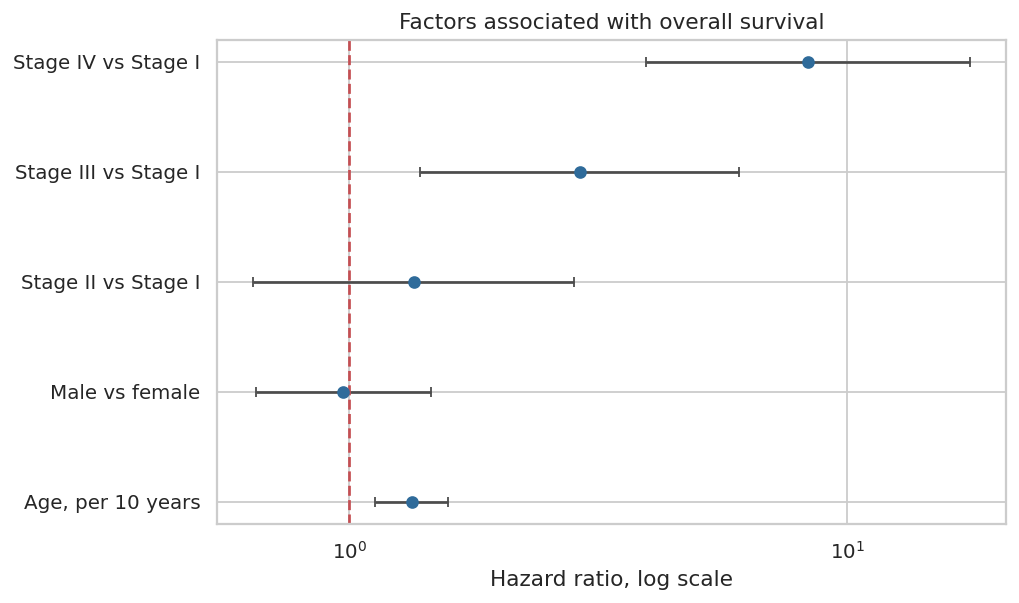

In [7]:
stage_cat = cox_df.copy()
stage_cat["stage_group"] = pd.Categorical(
    stage_cat["stage_group"], categories=stage_order, ordered=True
)
stage_dummies = pd.get_dummies(stage_cat[["stage_group"]], drop_first=True, dtype=float)
stage_model_df = pd.concat(
    [
        stage_cat[["os_time_days", "os_event", "age_per_10_years", "male"]],
        stage_dummies,
    ],
    axis=1,
)

stage_model = CoxPHFitter(penalizer=0.01)
stage_model.fit(stage_model_df, duration_col="os_time_days", event_col="os_event")
stage_summary = stage_model.summary[
    ["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]
].rename(
    columns={
        "exp(coef)": "hazard_ratio",
        "exp(coef) lower 95%": "hr_95ci_low",
        "exp(coef) upper 95%": "hr_95ci_high",
    }
)
stage_summary = stage_summary.rename(
    index={
        "age_per_10_years": "Age, per 10 years",
        "male": "Male vs female",
        "stage_group_Stage II": "Stage II vs Stage I",
        "stage_group_Stage III": "Stage III vs Stage I",
        "stage_group_Stage IV": "Stage IV vs Stage I",
    }
)

display(
    stage_summary.round(
        {"hazard_ratio": 2, "hr_95ci_low": 2, "hr_95ci_high": 2, "p": 4}
    )
)

plot_df = stage_summary.reset_index(names="factor").copy()
plot_df["factor"] = pd.Categorical(
    plot_df["factor"], categories=plot_df["factor"][::-1], ordered=True
)
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.errorbar(
    plot_df["hazard_ratio"],
    plot_df["factor"],
    xerr=[
        plot_df["hazard_ratio"] - plot_df["hr_95ci_low"],
        plot_df["hr_95ci_high"] - plot_df["hazard_ratio"],
    ],
    fmt="o",
    color="#2F6B9A",
    ecolor="#4C4C4C",
    capsize=3,
)
ax.axvline(1, color="#C44E52", linestyle="--", linewidth=1.5)
ax.set_xscale("log")
ax.set_xlabel("Hazard ratio, log scale")
ax.set_ylabel("")
ax.set_title("Factors associated with overall survival")
fig.tight_layout()
fig.savefig(REPORT_DIR / "coad_prognosis_cox_forest.png", bbox_inches="tight")
plt.show()

In [8]:
median_age = df["age"].median()
q1_age = df["age"].quantile(0.25)
q3_age = df["age"].quantile(0.75)
stage_iv_5y = survival_rate_table.loc[
    survival_rate_table["stage"] == "Stage IV", "5_year_survival"
].iloc[0]
stage_i_5y = survival_rate_table.loc[
    survival_rate_table["stage"] == "Stage I", "5_year_survival"
].iloc[0]
stage_hr = compact_summary.loc["Stage, per level increase", "hazard_ratio"]
age_hr = compact_summary.loc["Age, per 10 years", "hazard_ratio"]
gender_p = compact_summary.loc["Male vs female", "p"]

conclusion = f"""
## Final Answers

1. **Age distribution:** COAD patients in this dataset are mostly older adults. The median age is **{median_age:.0f} years**, and the middle 50% are **{q1_age:.0f}-{q3_age:.0f} years** old.

2. **Survival by stage:** Survival differs strongly by stage. The log-rank p-value is **{logrank.p_value:.2e}**, meaning the stage survival curves are clearly different in this dataset. Estimated 5-year survival is about **{stage_i_5y:.1f}% for Stage I** versus **{stage_iv_5y:.1f}% for Stage IV**.

3. **Most prognosis-related factor:** **Stage is the strongest of the three factors.** In the Cox model, each one-level increase in stage has HR about **{stage_hr:.2f}**, meaning higher stage is linked with much higher death risk. Age also matters: every 10-year increase has HR about **{age_hr:.2f}**. Gender is not clearly related to prognosis here (p = **{gender_p:.3f}**).

**Plain English summary:** stage matters most, age matters somewhat, and gender does not show a strong signal in this TCGA COAD clinical dataset.

**中文简要总结:** stage（分期）和预后关系最强；年龄也有一定关系；性别在这个数据集中没有明显关系。

## Limitations

- This is association, not causation (相关不等于因果).
- TCGA follow-up times vary by patient, so Kaplan-Meier and Cox models are used to handle censoring (删失：没有观察到死亡事件但知道随访时间).
- Stage IV has fewer patients than Stage II, so its confidence interval is wider.
- More complete prognosis modeling should also include treatment, molecular subtype, recurrence, and gene expression features.
"""
display(Markdown(conclusion))


## Final Answers

1. **Age distribution:** COAD patients in this dataset are mostly older adults. The median age is **68 years**, and the middle 50% are **58-77 years** old.

2. **Survival by stage:** Survival differs strongly by stage. The log-rank p-value is **3.98e-13**, meaning the stage survival curves are clearly different in this dataset. Estimated 5-year survival is about **78.9% for Stage I** versus **37.1% for Stage IV**.

3. **Most prognosis-related factor:** **Stage is the strongest of the three factors.** In the Cox model, each one-level increase in stage has HR about **2.36**, meaning higher stage is linked with much higher death risk. Age also matters: every 10-year increase has HR about **1.34**. Gender is not clearly related to prognosis here (p = **0.905**).

**Plain English summary:** stage matters most, age matters somewhat, and gender does not show a strong signal in this TCGA COAD clinical dataset.

**中文简要总结:** stage（分期）和预后关系最强；年龄也有一定关系；性别在这个数据集中没有明显关系。

## Limitations

- This is association, not causation (相关不等于因果).
- TCGA follow-up times vary by patient, so Kaplan-Meier and Cox models are used to handle censoring (删失：没有观察到死亡事件但知道随访时间).
- Stage IV has fewer patients than Stage II, so its confidence interval is wider.
- More complete prognosis modeling should also include treatment, molecular subtype, recurrence, and gene expression features.
